In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
pip install flair[word-embeddings]

In [9]:
!pip install flair

# ASSIGNMENT 1: Training your own NER model

In this lab we will train a NER model in a **language of your interest** and use it to tag texts for that language. To train a NER (SequenceTagger) model we need the following:


1. An annotated corpus in the IOB2 format. You can load your own or use one of the many available in Flair:https://flairnlp.github.io/flair/v0.13.1/tutorial/tutorial-training/index.html
  + CoNLL 2003 for English and German are not publicly available but you can find the required files in the following google drive folder:
  '/content/drive/My Drive/Colab Notebooks/2025-ILTAPP/datasets/ner'
2. At least one WordEmbedding or FlairEmbeddings. You can check the ones available in the tutorial.
  + Static Word Embeddings: https://flairnlp.github.io/flair/v0.13.1/tutorial/tutorial-embeddings/classic-word-embeddings.html
  + FlairEmbeddings: https://flairnlp.github.io/flair/v0.13.1/tutorial/tutorial-embeddings/flair-embeddings.html
  + NOTE: Remember that the embeddings can be combined (Stacked): https://flairnlp.github.io/flair/v0.13.1/tutorial/tutorial-embeddings/embeddings.html#how-to-stack-embeddings
3. Instantiate a SequenceTagger and a Model Trainer: https://flairnlp.github.io/flair/v0.13.1/tutorial/tutorial-training/index.html
4. Run! (perhaps consider downsampling the training data and setting at first a lower number of epochs, just to check that the training works).
5. HINT: You can also print your corpus statistics using the corpus obtain_statistics() function. This will give you an idea of the size of your dataset.

In [10]:
from flair.data import Corpus
from flair.datasets import ColumnCorpus
from flair.embeddings import TokenEmbeddings, WordEmbeddings, StackedEmbeddings, FlairEmbeddings
from typing import List

In [11]:
import pandas as pd
import csv # Import the csv module for quoting options
columns = {0:'text', 1:'ner'}

data_folder = '/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/ner'

# Define full paths to the files
train_file_path = f'{data_folder}/en-train.tsv'
dev_file_path = f'{data_folder}/en-testa.tsv'
test_file_path = f'{data_folder}/en-testb.tsv'

# Load each file into a pandas DataFrame, specifying no quoting
train_df = pd.read_csv(train_file_path, sep='\t', header=None, names=['text', 'ner'], quoting=csv.QUOTE_NONE)
dev_df = pd.read_csv(dev_file_path, sep='\t', header=None, names=['text', 'ner'], quoting=csv.QUOTE_NONE)
test_df = pd.read_csv(test_file_path, sep='\t', header=None, names=['text', 'ner'], quoting=csv.QUOTE_NONE)

print("Train DataFrame Head:")
display(train_df.head())

print("\nDev DataFrame Head:")
display(dev_df.head())

print("\nTest DataFrame Head:")
display(test_df.head())

Train DataFrame Head:


,text,ner
0,-DOCSTART-,O
1,EU,I-ORG
2,rejects,O
3,German,I-MISC
4,call,O



Dev DataFrame Head:


,text,ner
0,-DOCSTART-,O
1,CRICKET,O
2,-,O
3,LEICESTERSHIRE,I-ORG
4,TAKE,O



Test DataFrame Head:


,text,ner
0,-DOCSTART-,O
1,SOCCER,O
2,-,O
3,JAPAN,I-LOC
4,GET,O


In [12]:
# 2. what tag do we want to predict?
tag_type = 'ner'

# Define the data folder and columns again, as this cell needs them
data_folder = '/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/ner'
columns = {0:'text', 1:'ner'}

# Create the ColumnCorpus object
from flair.data import Corpus
from flair.datasets import ColumnCorpus
corpus: Corpus = ColumnCorpus(data_folder, columns,
                              train_file='en-train.tsv',
                              test_file='en-testb.tsv',
                              dev_file='en-testa.tsv')

# 3. make the tag dictionary from the corpus
tag_dictionary = corpus.make_label_dictionary(label_type=tag_type)
print(tag_dictionary.idx2item)

# Optional: print corpus statistics as suggested in the original assignment
print("\nCorpus Statistics:")
print(corpus.obtain_statistics(pretty_print=True))

2026-03-03 16:52:46,107 Reading data from /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/ner
2026-03-03 16:52:46,109 Train: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/ner/en-train.tsv
2026-03-03 16:52:46,110 Dev: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/ner/en-testa.tsv
2026-03-03 16:52:46,112 Test: /content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/datasets/ner/en-testb.tsv
2026-03-03 16:52:55,926 Computing label dictionary. Progress:


1it [00:00, 1421.80it/s]
14987it [00:00, 22243.33it/s]

2026-03-03 16:52:56,630 Dictionary created for label 'ner' with 4 values: LOC (seen 7140 times), PER (seen 6600 times), ORG (seen 6321 times), MISC (seen 3438 times)


[b'LOC', b'PER', b'ORG', b'MISC']

Corpus Statistics:
{
    "TRAIN": {
        "dataset": "TRAIN",
        "total_number_of_documents": 14987,
        "number_of_documents_per_class": {
            "ORG": 6321,
            "MISC": 3438,
            "PER": 6600,
            "LOC": 7140
        },
        "number_of_tokens_per_tag": {},
        "number_of_tokens": {
            "total": 204567,
            "min": 1,
            "max": 113,
            "avg": 13.649629679055181
        }
    },
    "TEST": {
        "dataset": "TEST",
        "total_number_of_documents": 3684,
        "number_of_documents_per_class": {
            "LOC": 1668,
            "PER": 1617,
            "MISC": 702,
            "ORG": 1661
        },
        "number_of_tokens_per_tag": {},
        "number_of_tokens": {
            "total": 46666,
            "min": 1,
            "max": 124,
            "avg": 12.667209554831704
        }
    },
    "DEV": {
        "dataset": "DEV",
        "total_number_of_doc

In [13]:
# TODO initialize embeddings (output below refers to WordEmbeddings('eu'),
# FlairEmbeddings('eu-forward') and FlairEmbeddings('eu-backward'))
from flair.embeddings import TokenEmbeddings, WordEmbeddings, StackedEmbeddings, FlairEmbeddings

embedding_types: List[TokenEmbeddings] = [
    WordEmbeddings('glove'),
    FlairEmbeddings('news-forward'),
    FlairEmbeddings('news-backward'),
]

embeddings: StackedEmbeddings = StackedEmbeddings(embeddings=embedding_types)




2026-03-03 16:52:57,705 https://flair.informatik.hu-berlin.de/resources/embeddings/token/glove.gensim.vectors.npy not found in cache, downloading to /tmp/tmpby06k0vn


100%|██████████| 153M/153M [00:10<00:00, 16.0MB/s]

2026-03-03 16:53:08,185 copying /tmp/tmpby06k0vn to cache at /root/.flair/embeddings/glove.gensim.vectors.npy


2026-03-03 16:53:08,347 removing temp file /tmp/tmpby06k0vn
2026-03-03 16:53:08,840 https://flair.informatik.hu-berlin.de/resources/embeddings/token/glove.gensim not found in cache, downloading to /tmp/tmppeawg2fc


100%|██████████| 20.5M/20.5M [00:02<00:00, 9.32MB/s]

...

100%|██████████| 69.7M/69.7M [00:06<00:00, 10.7MB/s]

2026-03-03 16:53:22,468 copying /tmp/tmpt0gfk3mf to cache at /root/.flair/embeddings/news-forward-0.4.1.pt
2026-03-03 16:53:22,524 removing temp file /tmp/tmpt0gfk3mf


2026-03-03 16:53:23,902 https://flair.informatik.hu-berlin.de/resources/embeddings/flair/news-backward-0.4.1.pt not found in cache, downloading to /tmp/tmprzbnueyy


100%|██████████| 69.7M/69.7M [00:04<00:00, 15.0MB/s]

2026-03-03 16:53:29,231 copying /tmp/tmprzbnueyy to cache at /root/.flair/embeddings/news-backward-0.4.1.pt
2026-03-03 16:53:29,274 removing temp file /tmp/tmprzbnueyy


In [14]:
# TODO initialize sequence tagger
from flair.models import SequenceTagger

tagger: SequenceTagger = SequenceTagger(
    hidden_size=256,
    embeddings=embeddings,
    tag_dictionary=tag_dictionary,
    tag_type=tag_type,
    use_crf=True
)


2026-03-03 16:53:29,543 SequenceTagger predicts: Dictionary with 17 tags: O, S-LOC, B-LOC, E-LOC, I-LOC, S-PER, B-PER, E-PER, I-PER, S-ORG, B-ORG, E-ORG, I-ORG, S-MISC, B-MISC, E-MISC, I-MISC


In [15]:
# TODO initialize trainer
from flair.trainers import ModelTrainer

trainer: ModelTrainer = ModelTrainer(tagger, corpus)

In [16]:
# TODO train
# saving the model into your drive (need to provide the full path of the folder in which you want to save the model)
# results obtained with the BASQUE NER corpus over 10 epochs (inspect the output generated below)

model_save_path = '/content/drive/My Drive/Colab Notebooks/2026-ILTAPP//2026-ILTAPP/en-flair-model'

trainer.train(
    model_save_path,
    learning_rate=0.1,
    mini_batch_size=32,
    max_epochs=10
)

2026-03-03 16:53:30,803 ----------------------------------------------------------------------------------------------------
2026-03-03 16:53:30,804 Model: "SequenceTagger(
  (embeddings): StackedEmbeddings(
    (list_embedding_0): WordEmbeddings(
      'glove'
      (embedding): Embedding(400001, 100)
    )
    (list_embedding_1): FlairEmbeddings(
      (lm): LanguageModel(
        (drop): Dropout(p=0.05, inplace=False)
        (encoder): Embedding(300, 100)
        (rnn): LSTM(100, 2048)
      )
    )
    (list_embedding_2): FlairEmbeddings(
      (lm): LanguageModel(
        (drop): Dropout(p=0.05, inplace=False)
        (encoder): Embedding(300, 100)
        (rnn): LSTM(100, 2048)
      )
    )
  )
  (word_dropout): WordDropout(p=0.05)
  (locked_dropout): LockedDropout(p=0.5)
  (embedding2nn): Linear(in_features=4196, out_features=4196, bias=True)
  (rnn): LSTM(4196, 256, batch_first=True, bidirectional=True)
  (linear): Linear(in_features=512, out_features=19, bias=True)
  (loss_f

/usr/local/lib/python3.12/dist-packages/flair/trainers/trainer.py:107: UserWarning: There should be no best model saved at epoch 1 except there is a model from previous trainings in your training folder. All previous best models will be deleted.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/flair/trainers/trainer.py:545: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp and flair.device.type != "cpu")


2026-03-03 16:53:48,308 epoch 1 - iter 46/469 - loss 0.70113643 - time (sec): 17.47 - samples/sec: 1164.71 - lr: 0.100000 - momentum: 0.000000
2026-03-03 16:54:05,751 epoch 1 - iter 92/469 - loss 0.50305662 - time (sec): 34.91 - samples/sec: 1172.53 - lr: 0.100000 - momentum: 0.000000
2026-03-03 16:54:23,392 epoch 1 - iter 138/469 - loss 0.40832970 - time (sec): 52.56 - samples/sec: 1169.97 - lr: 0.100000 - momentum: 0.000000
2026-03-03 16:54:42,182 epoch 1 - iter 184/469 - loss 0.35105740 - time (sec): 71.35 - samples/sec: 1144.42 - lr: 0.100000 - momentum: 0.000000
2026-03-03 16:55:00,750 epoch 1 - iter 230/469 - loss 0.31786851 - time (sec): 89.91 - samples/sec: 1124.32 - lr: 0.100000 - momentum: 0.000000
2026-03-03 16:55:20,522 epoch 1 - iter 276/469 - loss 0.29200474 - time (sec): 109.68 - samples/sec: 1098.42 - lr: 0.100000 - momentum: 0.000000
2026-03-03 16:55:42,991 epoch 1 - iter 322/469 - loss 0.26953980 - time (sec): 132.15 - samples/sec: 1065.10 - lr: 0.100000 - momentum: 0

100%|██████████| 55/55 [00:40<00:00,  1.36it/s]


2026-03-03 16:57:30,546 DEV : loss 0.07097790390253067 - f1-score (micro avg)  0.889
2026-03-03 16:57:30,715  - 0 epochs without improvement
2026-03-03 16:57:31,059 saving best model
2026-03-03 16:57:37,572 ----------------------------------------------------------------------------------------------------
2026-03-03 16:57:42,817 epoch 2 - iter 46/469 - loss 0.10883939 - time (sec): 5.24 - samples/sec: 3921.97 - lr: 0.100000 - momentum: 0.000000
2026-03-03 16:57:47,502 epoch 2 - iter 92/469 - loss 0.11254465 - time (sec): 9.93 - samples/sec: 4034.63 - lr: 0.100000 - momentum: 0.000000
2026-03-03 16:57:54,141 epoch 2 - iter 138/469 - loss 0.10936055 - time (sec): 16.57 - samples/sec: 3590.76 - lr: 0.100000 - momentum: 0.000000
2026-03-03 16:57:58,835 epoch 2 - iter 184/469 - loss 0.10573165 - time (sec): 21.26 - samples/sec: 3739.27 - lr: 0.100000 - momentum: 0.000000
2026-03-03 16:58:03,782 epoch 2 - iter 230/469 - loss 0.10258512 - time (sec): 26.21 - samples/sec: 3817.65 - lr: 0.1000

...

2026-03-03 17:08:01,254 DEV : loss 0.03294369950890541 - f1-score (micro avg)  0.9474


2026-03-03 17:08:01,417  - 0 epochs without improvement
2026-03-03 17:08:01,423 saving best model
2026-03-03 17:08:22,136 ----------------------------------------------------------------------------------------------------
2026-03-03 17:08:22,156 Loading model from best epoch ...
2026-03-03 17:08:24,685 SequenceTagger predicts: Dictionary with 19 tags: O, S-LOC, B-LOC, E-LOC, I-LOC, S-PER, B-PER, E-PER, I-PER, S-ORG, B-ORG, E-ORG, I-ORG, S-MISC, B-MISC, E-MISC, I-MISC, <START>, <STOP>


100%|██████████| 58/58 [00:28<00:00,  2.01it/s]


2026-03-03 17:08:54,318 
Results:
- F-score (micro) 0.917
- F-score (macro) 0.9026
- Accuracy 0.8758

By class:
              precision    recall  f1-score   support

         ORG     0.8697    0.9163    0.8924      1661
         LOC     0.9416    0.9287    0.9351      1668
         PER     0.9685    0.9703    0.9694      1617
        MISC     0.8134    0.8134    0.8134       702

   micro avg     0.9115    0.9226    0.9170      5648
   macro avg     0.8983    0.9072    0.9026      5648
weighted avg     0.9122    0.9226    0.9172      5648

2026-03-03 17:08:54,320 ----------------------------------------------------------------------------------------------------


{'test_score': 0.9170259568851737}

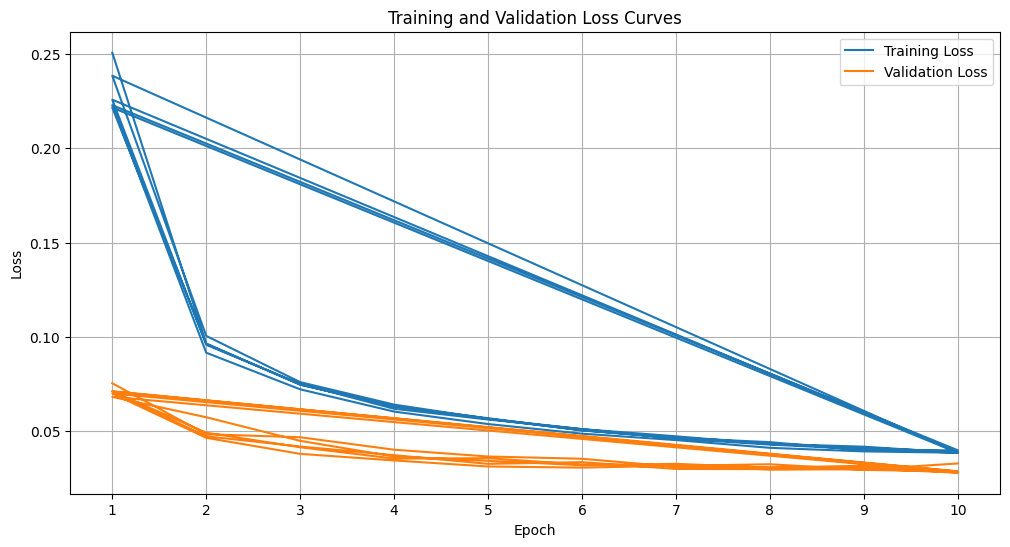

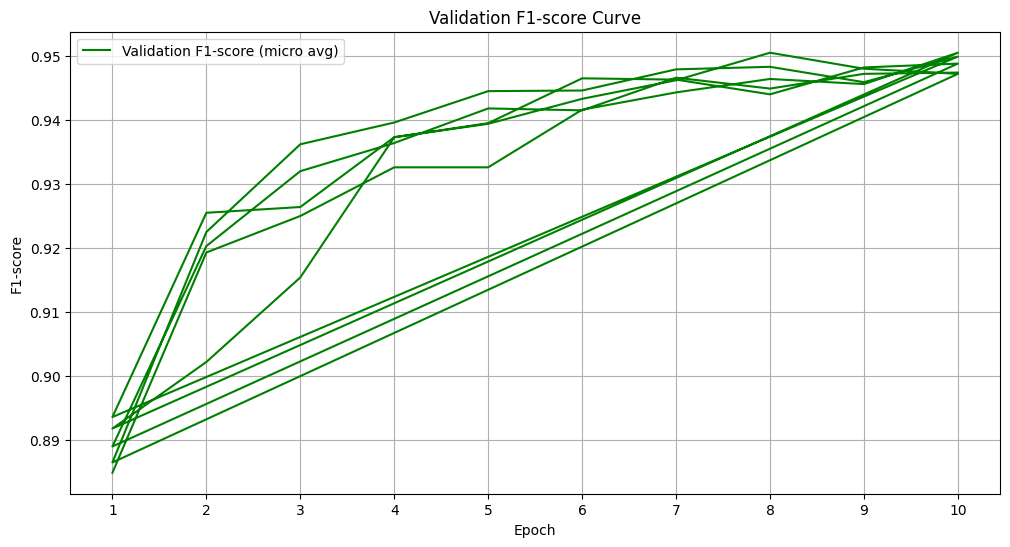

Error: The file /content/drive/My Drive/Colab Notebooks/2026-ILTAPP//2026-ILTAPP/en-flair-model/weights.txt was not found.


In [17]:
# plot training loss and weights
# HINT Check documentation on training models with Flair

import pandas as pd
import matplotlib.pyplot as plt

# Construct the full path to the loss.tsv file
loss_file_path = f'{model_save_path}/loss.tsv'

try:
    # Read the TSV file into a pandas DataFrame
    # The sep='\t' specifies tab-separated values
    # header=0 indicates the first row is the header
    df_loss = pd.read_csv(loss_file_path, sep='\t', header=0)

    # Convert relevant columns to numeric, coercing errors to NaN
    df_loss['TRAIN_LOSS'] = pd.to_numeric(df_loss['TRAIN_LOSS'], errors='coerce')
    df_loss['DEV_LOSS'] = pd.to_numeric(df_loss['DEV_LOSS'], errors='coerce')
    df_loss['DEV_F1'] = pd.to_numeric(df_loss['DEV_F1'], errors='coerce') # Corrected from DEV_SCORE to DEV_F1

    # Drop rows where critical plotting data is missing (NaN)
    df_loss.dropna(subset=['TRAIN_LOSS', 'DEV_LOSS', 'DEV_F1'], inplace=True)

    # Plotting training and development loss
    plt.figure(figsize=(12, 6))
    plt.plot(df_loss['EPOCH'], df_loss['TRAIN_LOSS'], label='Training Loss')
    plt.plot(df_loss['EPOCH'], df_loss['DEV_LOSS'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plotting development F1-score
    plt.figure(figsize=(12, 6))
    plt.plot(df_loss['EPOCH'], df_loss['DEV_F1'], label='Validation F1-score (micro avg)', color='green') # Corrected from DEV_SCORE to DEV_F1
    plt.xlabel('Epoch')
    plt.ylabel('F1-score')
    plt.title('Validation F1-score Curve')
    plt.legend()
    plt.grid(True)
    plt.show()

except FileNotFoundError:
    print(f"Error: The file {loss_file_path} was not found.")
except KeyError as e:
    print(f"Error: Missing expected column in loss.tsv: {e}. Please check the file format.")
except Exception as e:
    print(f"An unexpected error occurred during plotting: {e}")

# Attempt to plot weights if the file exists
# The flair.visual.training_curves.Plotter is still useful for weights,
# as it is not affected by the same parsing issue as plot_training_curves for loss.tsv.
from flair.visual.training_curves import Plotter
plotter = Plotter()
try:
    plotter.plot_weights(f'{model_save_path}/weights.txt')
except FileNotFoundError:
    print(f"Error: The file {model_save_path}/weights.txt was not found.")
except Exception as e:
    print(f"An error occurred while plotting weights: {e}")

# ASSIGNMENT 2: Tag a document of your choice

In this assignment we will use the model trained in the previous step to automatically tag a document of your choice.

1. HINT: Revise the TUTORIAL_2_TAGGING to see how to use a SequenceTagger to tag texts. Remember that to use your own model you need to instantiate the SequenceTagger providing the full path of your model, like so:

```
ner_tagger = SequenceTagger.load('/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/eu-flair-model/final-model.pt')
```

2. Save the document in your drive as a plain text file.
3. Load the file and instantiate the SequenceTagger with your model.
4. Predict the NER tags with your model.
5. Inspect the annotations obtained. You can do this in various ways:
  + By saving the annotated file to a text document in your drive.
  + By inspecting the annotations via iteration over the Sentence objects to extract the ner annotations for each token.


In [18]:
# Step 3: Load model and text file
from flair.models import SequenceTagger
from flair.data import Sentence
import os

ner_tagger = SequenceTagger.load(f'{model_save_path}/final-model.pt')

# Define the full path for the document
document_path = '/content/drive/My Drive/Colab Notebooks/2026-ILTAPP/2026-ILTAPP/Gaurdian_article.txt'

with open(document_path, 'r') as f:
    raw_text = f.read()

sentences = [Sentence(line.strip()) for line in raw_text.split('\n') if line.strip()]

2026-03-03 17:08:56,618 SequenceTagger predicts: Dictionary with 19 tags: O, S-LOC, B-LOC, E-LOC, I-LOC, S-PER, B-PER, E-PER, I-PER, S-ORG, B-ORG, E-ORG, I-ORG, S-MISC, B-MISC, E-MISC, I-MISC, <START>, <STOP>


In [19]:
# Step 4: Predict
# The sentences object is now populated in the previous cell.
ner_tagger.predict(sentences)

In [20]:
# Step 5: Inspect annotations
for sentence in sentences:
    for entity in sentence.get_spans('ner'):
        print(f'"{entity.text}" => {entity.get_label("ner").value} ({entity.get_label("ner").score:.4f})')

"Iran" => LOC (0.9963)
"AI-powered" => MISC (0.7257)
"Robert Booth" => PER (0.9968)
"Dan Milmo" => PER (0.9977)
"AI" => ORG (0.7796)
"Iran" => LOC (0.9998)
"Anthropic" => ORG (0.3405)
"AI" => ORG (0.7569)
"Claude" => PER (0.9615)
"US" => LOC (0.8611)
"Guardian" => ORG (0.6107)
"US" => LOC (0.9765)
"Israel" => LOC (0.9989)
"AI" => ORG (0.9426)
"Gaza" => LOC (0.9980)
"Iranian" => MISC (0.9684)
"Israeli" => MISC (0.9014)
"Iran" => LOC (0.9999)
"Ayatollah Ali Khamenei" => PER (0.9493)
"AI" => ORG (0.8924)
"San Francisco-based" => MISC (0.6241)
"Anthropic" => ORG (0.4638)
"US Department of War" => ORG (0.8916)
"Claude" => PER (0.9941)
"Palantir" => ORG (0.9676)
"Pentagon" => ORG (0.9393)
"AI" => ORG (0.7903)
"Craig Jones" => PER (0.9987)
"Newcastle University" => ORG (0.9452)
"AI" => ORG (0.7284)
"Palantir" => ORG (0.9726)
"David Leslie" => PER (0.9972)
"Queen Mary" => LOC (0.7656)
"University of London" => ORG (0.8727)
"AI" => ORG (0.6912)
"AI" => ORG (0.8912)
"Iran" => LOC (0.9997)
"UN" =